# 🔬 Skin Lesion Classification — Full PyTorch Pipeline
> StyleGAN2 data generation + EfficientNet classifier + WandB logging

**Runtime:** `Runtime → Change runtime type → T4 GPU`

## 1️⃣  Mount Drive & Cài thư viện

In [10]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install wandb timm -q
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch /content/stylegan2ada -q
import sys
sys.path.insert(0, '/content/stylegan2ada')

print('Done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path '/content/stylegan2ada' already exists and is not an empty directory.
Done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2️⃣  Login WandB

In [4]:
import wandb
wandb.login()  # Nhập API key từ https://wandb.ai/settings

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: khoaanh05 (khoaanh05-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3️⃣  Config

In [5]:
import os

BASE = '/content/drive/MyDrive/skin_lesion'

CONFIG = {
    # --- Paths ---
    'csv_path'   : f'{BASE}/Data/HAM10000_sample_data.csv.csv',
    'img_dirs'   : [
        f'{BASE}/Data/processed_HAM10000_part_1',
        f'{BASE}/Data/processed_HAM10000_part_2',
    ],
    'pkl_paths'  : [
        f'{BASE}/Models/network-snapshot-000040.pkl',
        f'{BASE}/Models/network-snapshot-000080.pkl',
        f'{BASE}/Models/network-snapshot-000000.pkl',
        # thêm 2 file pkl còn lại nếu có
    ],
    'save_dir'   : f'{BASE}/outputs',
    'gen_dir'    : f'{BASE}/generated',

    # --- GAN ---
    'gen_per_class'   : 200,    # số ảnh generate thêm mỗi class
    'truncation_psi'  : 0.7,    # 0.5=chất lượng cao, 1.0=đa dạng cao

    # --- Training ---
    'img_size'        : 224,
    'batch_size'      : 32,
    'epochs'          : 30,
    'lr'              : 1e-4,
    'num_classes'     : 7,
    'num_workers'     : 2,
    'label_smoothing' : 0.1,
    'mixup_alpha'     : 0.2,

    # --- WandB ---
    'wandb_project'   : 'skin-lesion-pytorch',
    'wandb_run_name'  : 'efficientnet-stylegan-aug',
}

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']  # HAM10000

os.makedirs(CONFIG['save_dir'], exist_ok=True);
os.makedirs(CONFIG['gen_dir'],  exist_ok=True);
print(' Config OK')

 Config OK


## 4️⃣  Generate ảnh từ StyleGAN pkl

In [8]:
import os, glob, shutil, json
import pandas as pd
from pathlib import Path


all_generated = []

for pkl_path in CONFIG['pkl_paths']:
    print(f'\n Loading: {os.path.basename(pkl_path)}')

    for idx, cls_name in enumerate(CLASS_NAMES):
        cls_gen_dir = os.path.join(CONFIG['gen_dir'], cls_name)
        os.makedirs(cls_gen_dir, exist_ok=True)

        # Tạo seeds string
        seeds = f'0-{CONFIG["gen_per_class"]-1}'

        cmd = (
            f'python /content/stylegan2ada/generate.py '
            f'--outdir="{cls_gen_dir}" '
            f'--seeds={seeds} '
            f'--network="{pkl_path}" '
            f'--class={idx} '
            f'--trunc={CONFIG["truncation_psi"]}'
        )

        print(f'  Generating class {idx} ({cls_name})...')
        ret = os.system(cmd)

        if ret != 0:
            print(f'  Failed for {cls_name}, trying stylegan3 script...')
            cmd = cmd.replace('/content/stylegan2ada/generate.py',
                            '/content/stylegan3/gen_images.py')
            ret = os.system(cmd)

        # Collect generated paths
        imgs = sorted(glob.glob(os.path.join(cls_gen_dir, '*.png')) +
                      glob.glob(os.path.join(cls_gen_dir, '*.jpg')))
        rows = [{'path': p, 'label': idx} for p in imgs]
        all_generated.extend(rows)
        print(f'  {cls_name}: {len(rows)} ảnh')

print(f'\nTotal generated: {len(all_generated)} ảnh')


 Loading: network-snapshot-000040.pkl
  Generating class 0 (akiec)...
  akiec: 200 ảnh
  Generating class 1 (bcc)...
  bcc: 200 ảnh
  Generating class 2 (bkl)...
  bkl: 200 ảnh
  Generating class 3 (df)...
  df: 200 ảnh
  Generating class 4 (mel)...
  mel: 200 ảnh
  Generating class 5 (nv)...
  nv: 200 ảnh
  Generating class 6 (vasc)...
  vasc: 200 ảnh

 Loading: network-snapshot-000080.pkl
  Generating class 0 (akiec)...
  akiec: 200 ảnh
  Generating class 1 (bcc)...
  bcc: 200 ảnh
  Generating class 2 (bkl)...
  bkl: 200 ảnh
  Generating class 3 (df)...
  df: 200 ảnh
  Generating class 4 (mel)...
  mel: 200 ảnh
  Generating class 5 (nv)...
  nv: 200 ảnh
  Generating class 6 (vasc)...
  vasc: 200 ảnh

 Loading: network-snapshot-000000.pkl
  Generating class 0 (akiec)...
  akiec: 200 ảnh
  Generating class 1 (bcc)...
  bcc: 200 ảnh
  Generating class 2 (bkl)...
  bkl: 200 ảnh
  Generating class 3 (df)...
  df: 200 ảnh
  Generating class 4 (mel)...
  mel: 200 ảnh
  Generating class 5 (

## 5️⃣  Load & Kết hợp Dataset

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load CSV
df = pd.read_csv(CONFIG['csv_path'])

# Tìm đường dẫn ảnh thật từ 2 folder
def find_path(image_id):
    for d in CONFIG['img_dirs']:
        p = os.path.join(d, image_id + '.jpg')
        if os.path.exists(p):
            return p
    return None

df['filepath'] = df['image_id'].apply(find_path)
df = df.dropna(subset=['filepath'])

# Encode label
le = LabelEncoder().fit(CLASS_NAMES)
df['label'] = le.transform(df['dx'])

# Thêm ảnh generated
gen_df = pd.DataFrame(all_generated).rename(columns={'path': 'filepath'})
df_real = df[['filepath', 'label']].copy()
combined_df = pd.concat([df_real, gen_df], ignore_index=True)

print(f'Ảnh thật    : {len(df_real)}')
print(f'Ảnh generated: {len(gen_df)}')
print(f'Tổng         : {len(combined_df)}')

# Split
train_df, temp_df = train_test_split(combined_df, test_size=0.2, stratify=combined_df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df,     test_size=0.5, stratify=temp_df['label'],     random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Ảnh thật    : 5000
Ảnh generated: 4200
Tổng         : 9200
Train: 7360 | Val: 920 | Test: 920


## 6️⃣  PyTorch Dataset & DataLoader

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

train_transform = T.Compose([
    T.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])

val_transform = T.Compose([
    T.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['filepath']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = SkinDataset(train_df, train_transform)
val_ds   = SkinDataset(val_df,   val_transform)
test_ds  = SkinDataset(test_df,  val_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 230 | Val: 29 | Test: 29


## 7️⃣  Build Model (EfficientNet-B3 via timm)

In [11]:
import timm
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Tạo model với pretrained ImageNet weights
model = timm.create_model(
    'efficientnet_b3',
    pretrained=True,
    num_classes=CONFIG['num_classes']
)

# Freeze backbone, chỉ train classifier head trước
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

model = model.to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Params: {trainable:,} trainable / {total:,} total')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Params: 10,759 trainable / 10,706,991 total


## 8️⃣  Training Loop với WandB

In [12]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score

# Xử lý class imbalance
class_counts  = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum() * CONFIG['num_classes']

criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CONFIG['label_smoothing'])
optimizer  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)


run = wandb.init(
    project=CONFIG['wandb_project'],
    name=CONFIG['wandb_run_name'],
    config=CONFIG
)
wandb.watch(model, log='gradients', log_freq=100)

def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            preds = outputs.argmax(dim=1)
            total_loss += loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1

best_val_acc = 0
CKPT_PATH    = f"{CONFIG['save_dir']}/best_model.pth"

print(' Phase 1: Train classifier head (backbone frozen)\n')
for epoch in range(CONFIG['epochs']):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc,   val_f1   = run_epoch(val_loader,   is_train=False)
    scheduler.step()


    wandb.log({
        'epoch'      : epoch + 1,
        'train/loss' : train_loss, 'train/acc': train_acc, 'train/f1': train_f1,
        'val/loss'   : val_loss,   'val/acc'  : val_acc,   'val/f1'  : val_f1,
        'lr'         : scheduler.get_last_lr()[0],
    })

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'val_acc': val_acc}, CKPT_PATH)

    print(f'Epoch {epoch+1:02d}/{CONFIG["epochs"]} | '
          f'Train Loss={train_loss:.4f} Acc={train_acc:.3f} | '
          f'Val Loss={val_loss:.4f} Acc={val_acc:.3f} F1={val_f1:.3f}')

print(f'\n Phase 1 done. Best val acc: {best_val_acc:.4f}')

 Phase 1: Train classifier head (backbone frozen)

Epoch 01/30 | Train Loss=3.3731 Acc=0.184 | Val Loss=3.2897 Acc=0.220 F1=0.248
Epoch 02/30 | Train Loss=3.0937 Acc=0.231 | Val Loss=3.1457 Acc=0.276 F1=0.306
Epoch 03/30 | Train Loss=2.9652 Acc=0.254 | Val Loss=3.0519 Acc=0.291 F1=0.322
Epoch 04/30 | Train Loss=2.8732 Acc=0.280 | Val Loss=2.9372 Acc=0.300 F1=0.332
Epoch 05/30 | Train Loss=2.8214 Acc=0.287 | Val Loss=2.9151 Acc=0.307 F1=0.341
Epoch 06/30 | Train Loss=2.7849 Acc=0.294 | Val Loss=2.8652 Acc=0.320 F1=0.350
Epoch 07/30 | Train Loss=2.7285 Acc=0.303 | Val Loss=2.8122 Acc=0.322 F1=0.354
Epoch 08/30 | Train Loss=2.7162 Acc=0.311 | Val Loss=2.7625 Acc=0.333 F1=0.364
Epoch 09/30 | Train Loss=2.6779 Acc=0.314 | Val Loss=2.7240 Acc=0.327 F1=0.361
Epoch 10/30 | Train Loss=2.6118 Acc=0.316 | Val Loss=2.6818 Acc=0.324 F1=0.360
Epoch 11/30 | Train Loss=2.6248 Acc=0.312 | Val Loss=2.6437 Acc=0.337 F1=0.371
Epoch 12/30 | Train Loss=2.5785 Acc=0.315 | Val Loss=2.6451 Acc=0.323 F1=0.358
E

## 9️⃣  Fine-tuning (Unfreeze toàn bộ)

In [13]:
# Unfreeze tất cả
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-7)

print(' Phase 2: Fine-tuning (toàn bộ backbone)\n')
for epoch in range(15):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, is_train=True)
    val_loss,   val_acc,   val_f1   = run_epoch(val_loader,   is_train=False)
    scheduler.step()

    wandb.log({
        'epoch'      : CONFIG['epochs'] + epoch + 1,
        'train/loss' : train_loss, 'train/acc': train_acc, 'train/f1': train_f1,
        'val/loss'   : val_loss,   'val/acc'  : val_acc,   'val/f1'  : val_f1,
        'lr'         : scheduler.get_last_lr()[0],
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'val_acc': val_acc}, CKPT_PATH)

    print(f'FT Epoch {epoch+1:02d}/15 | '
          f'Train Acc={train_acc:.3f} | Val Acc={val_acc:.3f} F1={val_f1:.3f}')

print(f'\n Fine-tuning done. Best val acc: {best_val_acc:.4f}')

 Phase 2: Fine-tuning (toàn bộ backbone)

FT Epoch 01/15 | Train Acc=0.360 | Val Acc=0.375 F1=0.407
FT Epoch 02/15 | Train Acc=0.390 | Val Acc=0.395 F1=0.422
FT Epoch 03/15 | Train Acc=0.410 | Val Acc=0.415 F1=0.437
FT Epoch 04/15 | Train Acc=0.433 | Val Acc=0.442 F1=0.457
FT Epoch 05/15 | Train Acc=0.453 | Val Acc=0.443 F1=0.459
FT Epoch 06/15 | Train Acc=0.464 | Val Acc=0.465 F1=0.481
FT Epoch 07/15 | Train Acc=0.496 | Val Acc=0.466 F1=0.479
FT Epoch 08/15 | Train Acc=0.501 | Val Acc=0.482 F1=0.494
FT Epoch 09/15 | Train Acc=0.514 | Val Acc=0.471 F1=0.484
FT Epoch 10/15 | Train Acc=0.507 | Val Acc=0.489 F1=0.501
FT Epoch 11/15 | Train Acc=0.522 | Val Acc=0.490 F1=0.504
FT Epoch 12/15 | Train Acc=0.536 | Val Acc=0.511 F1=0.520
FT Epoch 13/15 | Train Acc=0.525 | Val Acc=0.507 F1=0.518
FT Epoch 14/15 | Train Acc=0.527 | Val Acc=0.502 F1=0.515
FT Epoch 15/15 | Train Acc=0.521 | Val Acc=0.504 F1=0.513

 Fine-tuning done. Best val acc: 0.5109


## 🔟  Evaluate & Log kết quả lên WandB

Loaded best model (val_acc=0.5109 @ epoch 12)

               precision    recall  f1-score   support

       akiec       0.22      0.08      0.11        79
         bcc       0.24      0.56      0.33        86
         bkl       0.32      0.22      0.26       117
          df       0.30      0.43      0.35        65
         mel       0.36      0.31      0.33       104
          nv       0.86      0.64      0.73       403
        vasc       0.31      0.61      0.41        66

    accuracy                           0.47       920
   macro avg       0.37      0.41      0.36       920
weighted avg       0.54      0.47      0.49       920



epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,█████▇▇▇▆▆▆▅▅▅▄▄▃▃▂▂▂▂▂▁▁▁▁▂▂▂▂▂▁▁▁▁▁▁▁▁
test/accuracy,▁
test/f1_weighted,▁
train/acc,▁▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▆▆▆▇▇█▇████
train/f1,▁▂▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▅▄▅▅▅▅▅▅▅▄▅▅▆▆▇▇▇█▇████
train/loss,█▇▆▆▆▆▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▄▄▄▄▄▃▃▂▂▂▁▁▁▁▁▁▁
val/acc,▁▂▃▃▃▃▃▄▄▄▃▄▄▄▄▄▄▄▄▄▅▄▄▄▄▄▄▅▅▆▆▆▇▇▇▇████
val/f1,▁▂▃▃▃▄▄▄▄▄▄▄▄▄▅▄▄▄▄▄▅▅▅▄▄▅▄▅▅▆▆▆▇▇▇█████
val/loss,█▇▇▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▄▄▄▄▃▃▂▂▂▁▁▁▁▁▁▁
epoch,45



 Xong! Xem kết quả tại https://wandb.ai


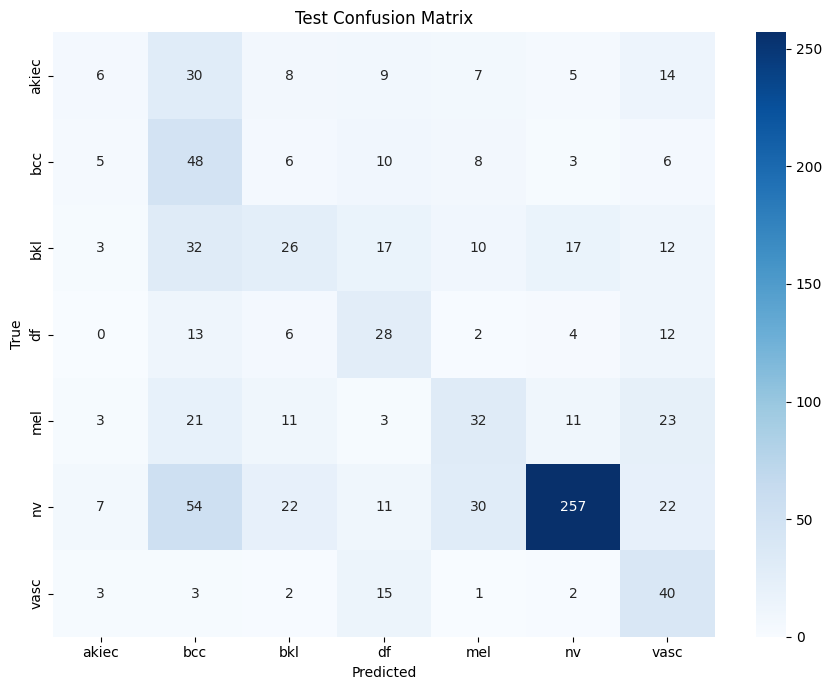

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best checkpoint
ckpt = torch.load(CKPT_PATH)
model.load_state_dict(ckpt['model'])
print(f'Loaded best model (val_acc={ckpt["val_acc"]:.4f} @ epoch {ckpt["epoch"]+1})')

# Predict
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Report
print('\n', classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix → WandB
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Test Confusion Matrix')
plt.tight_layout()

from sklearn.metrics import f1_score, accuracy_score
wandb.log({
    'test/confusion_matrix': wandb.Image(fig),
    'test/accuracy'        : accuracy_score(all_labels, all_preds),
    'test/f1_weighted'     : f1_score(all_labels, all_preds, average='weighted'),
})

# Upload best model artifact
artifact = wandb.Artifact('skin-lesion-model', type='model')
artifact.add_file(CKPT_PATH)
run.log_artifact(artifact)

wandb.finish()
print('\n Xong! Xem kết quả tại https://wandb.ai')